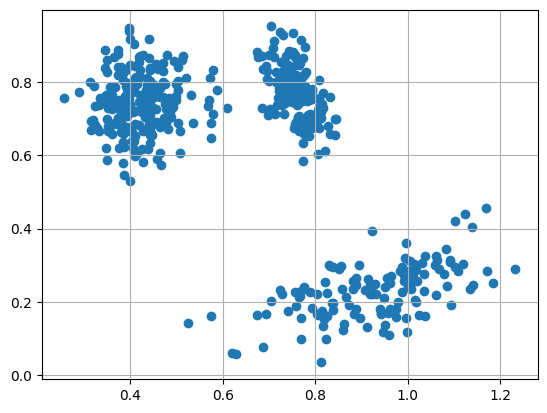

In [14]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Load data
X = np.genfromtxt("gm2d.csv", delimiter=",")
X = X[1:]
X = X[:, 1:] 
plt.scatter(X[:, 0], X[:, 1])
plt.grid()
plt.show();

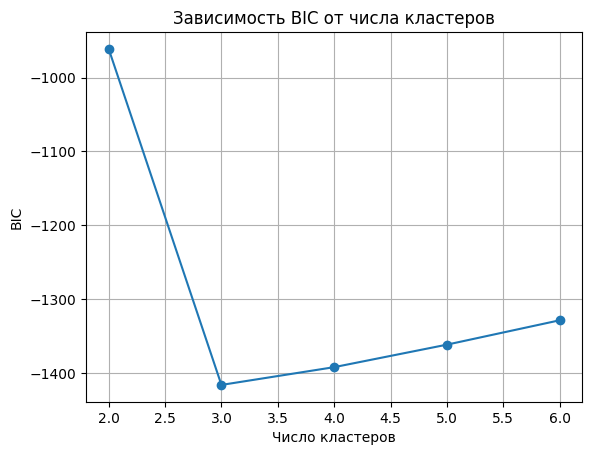

Оптимальное количество кластеров по критерию BIC: 3


In [16]:
from sklearn.mixture import GaussianMixture

ks = range(2, 7)
bics = []

for k in ks:
    best_bic = np.inf
    for seed in range(10):
        gmm = GaussianMixture(n_components=k, n_init=10, random_state=seed)
        gmm.fit(X)
        bic = gmm.bic(X)
        if bic < best_bic:
            best_bic = bic
    bics.append(best_bic)

plt.plot(list(ks), bics, marker="o")
plt.xlabel("Число кластеров")
plt.ylabel("BIC")
plt.title("Зависимость BIC от числа кластеров")
plt.grid()
plt.show()

optimal_k = ks[np.argmin(bics)]
print(f"Оптимальное количество кластеров по критерию BIC: {optimal_k}")

In [ ]:
#Вывод, при двух кластерах БИК выдает большие значения из за слишком маленького штрафа за сложность, а ещё данных было слишком много для двух кластеров
#Локальный минимум при трех кластерах бик